## Цель и задачи

Исследовать эффективность LLM различного масштаба для постобработки и коррекции ошибок систем автоматического распознавания речи (ASR). Провести сравнительный бенчмарк на матрице "6 ASR x 6 LLM x 5 датасетов" для английского и русского языков.

### Текущий этап

На данный момент реализован полный pipeline сравнительного бенчмарка: загрузка датасетов, baseline-прогон 6 ASR моделей, LLM-коррекция через HuggingFace Inference API, вычисление метрик WER/CER, построение визуализаций. Проведён прогон на 30 сэмплах для каждого из 114 экспериментов. Реализована система post-processing ответов LLM для защиты от галлюцинаций (clean_response с детекцией отказов, удалением мета-комментариев и обрезкой длинных ответов).

### ASR модели

| Модель | Параметры | Архитектура | Языки | Описание |
|--------|-----------|-------------|-------|----------|
| Whisper base | 74M | Encoder-Decoder | EN, RU | Мультиязычная модель OpenAI, обучена на 680k часов аудио. Компактная версия для быстрого inference |
| Whisper medium | 769M | Encoder-Decoder | EN, RU | Увеличенная версия Whisper с существенно лучшим качеством, особенно на зашумлённых данных |
| GigaAM v2 CTC | 240M | CTC | RU | Русскоязычная модель от Сбера, CTC-декодирование. Оптимизирована для русской речи |
| GigaAM v2 RNNT | 240M | RNN-Transducer | RU | Вариант GigaAM с RNNT-декодированием, потенциально лучше на потоковых данных |
| Wav2Vec2 XLS-R 1B | 1B | CTC (fine-tuned) | RU | Модель Meta, дообученная на русском. CTC без языковой модели - ошибки преимущественно лингвистические |
| Wav2Vec2 XLS-R 1B EN | 1B | CTC (fine-tuned) | EN | Та же архитектура, дообученная на английском. Позволяет сравнить эффект LLM на CTC-моделях для разных языков |

### LLM модели (HuggingFace Inference API)

| Модель | Параметры | Архитектура |Описание |
|--------|-----------|-------------|----------|
| Qwen2.5 7B | 7B | Dense | Компактная модель, baseline для сравнения с крупными |
| Llama 3.3 70B | 70B | Dense | Крупная dense-модель с сильной мультиязычной поддержкой |
| Qwen2.5 72B | 72B | Dense | Крупная dense-модель, прямое сравнение с Qwen2.5 7B по эффекту масштаба |
| GPT-OSS 120B | 120B  | MoE | Первая open-weight модель OpenAI, преимущественно англоцентричная |
| Qwen3 235B | 235B | MoE | Reasoning-модель нового поколения, позволяет оценить влияние chain-of-thought на коррекцию |
| DeepSeek V3 | 685B | MoE | Крупнейшая модель бенчмарка, сильная на русском, но склонна к галлюцинациям на английском |

### Датасеты речи

| Название | Язык | Стиль | Обоснование выбора |
|----------|------|-------|--------------------|
| LibriSpeech test-clean | EN | clean | Стандартный бенчмарк ASR, чистая студийная речь. Показывает поведение LLM при низком baseline WER |
| LibriSpeech test-other | EN | noisy | Тот же корпус, но с шумом и вариациями произношения. Сравнение с test-clean показывает влияние качества аудио |
| FLEURS English | EN | clean | Корпус Google с носителями языка. Дополнительный EN-датасет для перекрёстной проверки |
| FLEURS Russian | RU | clean | Чистая русская речь из того же корпуса FLEURS. Основной RU-датасет для всех моделей |
| SOVA audiobooks | RU | literary | Профессиональная литературная русская речь. Длинные предложения, редкая лексика - стресс-тест для LLM |

### Гипотезы

1. Более крупные LLM дают лучшую коррекцию ASR (сравнение Qwen2.5 7B vs 72B)
2. LLM-коррекция эффективнее при высоком baseline WER (более 15%)
3. При низком baseline WER (менее 10%) LLM-коррекция ухудшает результат
4. Dense-модели стабильнее MoE-моделей для задачи ASR-коррекции
5. Whisper medium (769M) существенно точнее Whisper base (74M), особенно на русском языке

---

## Установка зависимостей

In [3]:
%%capture
# Core
!pip install "datasets<3.6" soundfile librosa
!pip install openai-whisper jiwer tqdm openai
!pip install seaborn

# GigaAM (Sber)
!pip install git+https://github.com/salute-developers/GigaAM.git

# Wav2Vec2 XLS-R
!pip install "transformers>=4.45,<4.50" accelerate

## Импорты

In [4]:
import os
import re
import json
import time
import logging
import tempfile
import warnings
from dataclasses import dataclass
from dataclasses import field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import soundfile as sf
import torch
import whisper
import gigaam
from datasets import load_dataset
from openai import OpenAI
from jiwer import wer, cer
from tqdm.auto import tqdm
from google.colab import userdata


# Wav2Vec2
import transformers
transformers.utils.import_utils._torchvision_available = False
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# Seaborn
sns.set_theme(
    style='whitegrid',
    palette='husl',
    font_scale=1.1,
)

warnings.filterwarnings('ignore', category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
)
logger = logging.getLogger(__name__)

## Конфигурация класса бенчмарка

In [5]:
@dataclass
class BenchmarkConfig:
    """LLM benchmark configuration."""

    device: str = (
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    whisper_model: str = "base"
    gigaam_model: str = "v2_ctc"
    max_samples: int = 30
    llm_temperature: float = 0.1

    # HuggingFace Inference API models
    llm_models: list = field(default_factory=lambda: [
        {
            "id": "Qwen/Qwen2.5-7B-Instruct",
            "name": "Qwen2.5 7B",
            "params": "7B",
            "family": "Alibaba",
        },
        {
            "id": "meta-llama/Llama-3.3-70B-Instruct",
            "name": "Llama 3.3 70B",
            "params": "70B",
            "family": "Meta",
        },
        {
            "id": "Qwen/Qwen2.5-72B-Instruct",
            "name": "Qwen2.5 72B",
            "params": "72B",
            "family": "Alibaba",
        },
        {
            "id": "openai/gpt-oss-120b",
            "name": "GPT-OSS 120B",
            "params": "120B MoE",
            "family": "OpenAI",
        },
        {
            "id": "Qwen/Qwen3-235B-A22B",
            "name": "Qwen3 235B",
            "params": "235B MoE",
            "family": "Alibaba",
        },
        {
            "id": "deepseek-ai/DeepSeek-V3-0324",
            "name": "DeepSeek V3",
            "params": "685B MoE",
            "family": "DeepSeek",
        },
    ])


In [6]:
config = BenchmarkConfig()
print(f'Device: {config.device}')
print(f'LLM models: {len(config.llm_models)}')
for m in config.llm_models:
    print(f"  - {m['name']} ({m['params']})")

Device: cuda
LLM models: 6
  - Qwen2.5 7B (7B)
  - Llama 3.3 70B (70B)
  - Qwen2.5 72B (72B)
  - GPT-OSS 120B (120B MoE)
  - Qwen3 235B (235B MoE)
  - DeepSeek V3 (685B MoE)


## Вспомогательные функции

In [7]:
def normalize_text(
    text: str,
    lowercase: bool = True,
    remove_punctuation: bool = True,
) -> str:
    """Normalize text for WER/CER calculation."""

    if lowercase:
        text = text.lower()
    if remove_punctuation:
        text = re.sub(r'[.,!?;:"\'()\[\]{}\/\-\—\–]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [8]:
def calculate_wer(reference: str, hypothesis: str) -> float:
    """Calculate Word Error Rate."""

    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if not ref_norm:
        return 1.0 if hyp_norm else 0.0
    return wer(ref_norm, hyp_norm)


def calculate_cer(reference: str, hypothesis: str) -> float:
    """Calculate Character Error Rate."""

    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)
    if not ref_norm:
        return 1.0 if hyp_norm else 0.0
    return cer(ref_norm, hyp_norm)

In [9]:
def save_temp_wav(audio: np.ndarray, sample_rate: int = 16000) -> str:
    """Save audio to temporary WAV file."""

    tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
    sf.write(tmp.name, audio, sample_rate)
    return tmp.name


def resample_audio(
    audio: np.ndarray, orig_sr: int, target_sr: int = 16000,
) -> np.ndarray:
    """Resample audio to target sample rate."""

    if orig_sr == target_sr:
        return audio
    import librosa
    return librosa.resample(audio, orig_sr=orig_sr, target_sr=target_sr)

## Загрузка датасетов

In [10]:
#LIBRISPEECH


def _load_librispeech_split(
    config_name: str,
    split: str,
    max_samples: int,
    label: str,
) -> list[dict]:
    """Internal LibriSpeech loader for any split."""

    logger.info('Loading LibriSpeech %s...', label)
    ds = load_dataset(
        'librispeech_asr', config_name,
        split=split, streaming=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        samples.append({
            'audio': item['audio']['array'].astype(np.float32),
            'sample_rate': item['audio']['sampling_rate'],
            'reference': item['text'],
            'id': item.get('id', len(samples)),
        })
    logger.info(
        f'Loaded {len(samples)} EN samples from {label}'
    )
    return samples


def load_librispeech(max_samples: int = 50) -> list[dict]:
    """Load LibriSpeech test-clean."""

    return _load_librispeech_split(
        config_name='clean',
        split='test',
        max_samples=max_samples,
        label='test-clean',
    )


def load_librispeech_other(
    max_samples: int = 50,
) -> list[dict]:
    """Load LibriSpeech test-other."""

    return _load_librispeech_split(
        config_name='other',
        split='test',
        max_samples=max_samples,
        label='test-other',
    )


In [11]:
#FLEURS


def _load_fleurs_lang(
    config_name: str,
    max_samples: int,
    label: str,
    lang_log: str,
) -> list[dict]:
    """Internal FLEURS loader for any language config."""

    logger.info('Loading FLEURS %s...', label)
    ds = load_dataset(
        'google/fleurs', config_name,
        split='test', streaming=True,
        trust_remote_code=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        audio = item['audio']['array'].astype(np.float32)
        sr = item['audio']['sampling_rate']
        if sr != 16000:
            audio = resample_audio(audio, sr, 16000)
            sr = 16000
        samples.append({
            'audio': audio,
            'sample_rate': sr,
            'reference': item['transcription'],
            'id': item.get('id', len(samples)),
        })
    logger.info(f'Loaded {len(samples)} {lang_log} samples')
    return samples


def load_fleurs_ru(max_samples: int = 50) -> list[dict]:
    """Load Google FLEURS RU."""

    return _load_fleurs_lang(
        config_name='ru_ru',
        max_samples=max_samples,
        label='Russian',
        lang_log='RU',
    )


def load_fleurs_en(max_samples: int = 50) -> list[dict]:
    """Load Google FLEURS EN."""

    return _load_fleurs_lang(
        config_name='en_us',
        max_samples=max_samples,
        label='English',
        lang_log='EN',
    )

In [12]:
#SOVA


def load_sova_audiobooks(
    max_samples: int = 50,
) -> list[dict]:
    """Load SOVA RuDevices Audiobooks."""

    logger.info('Loading SOVA audiobooks...')
    ds = load_dataset(
        'dangrebenkin/sova_rudevices_audiobooks',
        split='test', streaming=True,
    )
    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        audio = item['audio']['array'].astype(np.float32)
        sr = item['audio']['sampling_rate']
        samples.append({
            'audio': audio,
            'sample_rate': sr,
            'reference': item['transcription'],
            'id': item.get('id', len(samples)),
        })
    logger.info(
        f'Loaded {len(samples)} RU samples from SOVA'
    )
    return samples

In [13]:
# загрузка датасетов

librispeech_clean_samples = load_librispeech(config.max_samples)

fleurs_ru_samples = load_fleurs_ru(config.max_samples)

librispeech_other_samples = load_librispeech_other(config.max_samples)

fleurs_en_samples = load_fleurs_en(config.max_samples)

sova_samples = load_sova_audiobooks(config.max_samples)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/997 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

### Реестр всех загруженных датасетов

In [14]:
# datasets_registry — единый реестр всех загруженных датасетов

datasets_registry = {
    'librispeech_test_clean': {
        'samples': librispeech_clean_samples,
        'language': 'en',
        'display_name': 'LibriSpeech test-clean',
        'domain': 'read_speech',
        'style': 'clean',
        'source': 'LibriSpeech',
    },
    'librispeech_test_other': {
        'samples': librispeech_other_samples,
        'language': 'en',
        'display_name': 'LibriSpeech test-other',
        'domain': 'read_speech',
        'style': 'noisy',
        'source': 'LibriSpeech',
    },
    'fleurs_en': {
        'samples': fleurs_en_samples,
        'language': 'en',
        'display_name': 'FLEURS English',
        'domain': 'read_speech',
        'style': 'clean',
        'source': 'Google FLEURS',
    },
    'fleurs_ru': {
        'samples': fleurs_ru_samples,
        'language': 'ru',
        'display_name': 'FLEURS Russian',
        'domain': 'read_speech',
        'style': 'clean',
        'source': 'Google FLEURS',
    },
    'sova_audiobooks_ru': {
        'samples': sova_samples,
        'language': 'ru',
        'display_name': 'SOVA audiobooks',
        'domain': 'read_speech',
        'style': 'literary',
        'source': 'SOVA.ai',
    },
}


In [15]:
print(f'Datasets registry: {len(datasets_registry)} datasets')
for key, meta in datasets_registry.items():
    n = len(meta['samples'])
    print(
        f"  [{key}] {meta['display_name']} "
        f"({meta['language']}, {meta['domain']}/{meta['style']}) "
        f"-> {n} samples"
    )

Datasets registry: 5 datasets
  [librispeech_test_clean] LibriSpeech test-clean (en, read_speech/clean) -> 30 samples
  [librispeech_test_other] LibriSpeech test-other (en, read_speech/noisy) -> 30 samples
  [fleurs_en] FLEURS English (en, read_speech/clean) -> 30 samples
  [fleurs_ru] FLEURS Russian (ru, read_speech/clean) -> 30 samples
  [sova_audiobooks_ru] SOVA audiobooks (ru, read_speech/literary) -> 30 samples


## Загрузка ASR моделей

In [16]:
MAX_DURATION_SEC = 25

# Whisper base
logger.info('Loading Whisper-base...')
whisper_base = whisper.load_model(
    'base', device=config.device,
)

# Whisper medium
logger.info('Loading Whisper-medium...')
whisper_medium = whisper.load_model(
    'medium', device=config.device,
)

# GigaAM v2 CTC
logger.info('Loading GigaAM-v2-CTC...')
gigaam_ctc_model = gigaam.load_model('v2_ctc')

# GigaAM v2 RNNT
logger.info('Loading GigaAM-v2-RNNT...')
gigaam_rnnt_model = gigaam.load_model('v2_rnnt')

# Wav2Vec2 XLS-R 1B Russian
WAV2VEC2_RU_ID = 'jonatasgrosman/wav2vec2-xls-r-1b-russian'
logger.info('Loading Wav2Vec2 XLS-R Russian...')
w2v_processor = Wav2Vec2Processor.from_pretrained(
    WAV2VEC2_RU_ID,
)
w2v_model = Wav2Vec2ForCTC.from_pretrained(
    WAV2VEC2_RU_ID,
).to(config.device)
w2v_model.eval()

# Wav2Vec2 XLS-R 1B English
WAV2VEC2_EN_ID = 'jonatasgrosman/wav2vec2-xls-r-1b-english'
logger.info('Loading Wav2Vec2 XLS-R English...')
w2v_en_processor = Wav2Vec2Processor.from_pretrained(
    WAV2VEC2_EN_ID,
)
w2v_en_model = Wav2Vec2ForCTC.from_pretrained(
    WAV2VEC2_EN_ID,
).to(config.device)
w2v_en_model.eval()

print('All ASR models loaded')

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 154MiB/s]
100%|█████████████████████████████████████| 1.42G/1.42G [00:17<00:00, 85.5MiB/s]
100%|███████████████████████████████████████| 444M/444M [00:40<00:00, 11.6MiB/s]
100%|███████████████████████████████████████| 448M/448M [00:30<00:00, 15.3MiB/s]


preprocessor_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

All ASR models loaded


### Функции транскрибирования ASR моделей

In [17]:
# Whisper

def transcribe_whisper_base(
    audio: np.ndarray, language: str = 'en',
) -> str:
    """Transcribe with Whisper base."""

    result = whisper_base.transcribe(
        audio, language=language,
        fp16=(config.device == 'cuda'),
    )
    return result['text'].strip()


def transcribe_whisper_medium(
    audio: np.ndarray, language: str = 'en',
) -> str:
    """Transcribe with Whisper medium."""

    result = whisper_medium.transcribe(
        audio, language=language,
        fp16=(config.device == 'cuda'),
    )
    return result['text'].strip()


In [18]:
# GigaAM

def _transcribe_gigaam_impl(
    model, audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Internal GigaAM transcribe for any v2 model."""

    max_len = MAX_DURATION_SEC * sample_rate
    if len(audio) > max_len:
        audio = audio[:max_len]
    path = save_temp_wav(audio, sample_rate)
    try:
        result = model.transcribe(path)
        if isinstance(result, str):
            text = result
        else:
            text = str(result)
    finally:
        os.unlink(path)
    return text.strip()


def transcribe_gigaam_ctc(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with GigaAM v2 CTC."""

    return _transcribe_gigaam_impl(
        gigaam_ctc_model, audio, sample_rate,
    )


def transcribe_gigaam_rnnt(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with GigaAM v2 RNNT."""

    return _transcribe_gigaam_impl(
        gigaam_rnnt_model, audio, sample_rate,
    )

In [19]:
# Wav2Vec2

def transcribe_wav2vec2(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with Wav2Vec2 XLS-R 1B RU."""

    inputs = w2v_processor(
        audio, sampling_rate=sample_rate,
        return_tensors='pt', padding=True,
    ).to(config.device)
    with torch.no_grad():
        logits = w2v_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    text = w2v_processor.batch_decode(pred_ids)[0]
    return text.strip()


def transcribe_wav2vec2_en(
    audio: np.ndarray, sample_rate: int = 16000,
) -> str:
    """Transcribe with Wav2Vec2 XLS-R 1B EN."""

    inputs = w2v_en_processor(
        audio, sampling_rate=sample_rate,
        return_tensors='pt', padding=True,
    ).to(config.device)
    with torch.no_grad():
        logits = w2v_en_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    text = w2v_en_processor.batch_decode(pred_ids)[0]
    return text.strip()

### Функция запуска baseline

In [20]:
def run_baseline(
    transcribe_fn, samples: list[dict],
    language: str = 'en', model_name: str = 'whisper',
) -> pd.DataFrame:
    """Run ASR baseline and compute WER/CER."""

    results = []

    for sample in tqdm(
        samples, desc=f'Baseline {model_name}',
    ):
        audio = sample['audio']
        sr = sample['sample_rate']

        if any(
            m in model_name
            for m in ['gigaam', 'wav2vec2']
        ):
            hyp = transcribe_fn(audio, sr)
        else:
            hyp = transcribe_fn(audio, language=language)

        ref = sample['reference']
        results.append({
            'id': sample['id'],
            'reference': ref,
            'hypothesis': hyp,
            'wer': calculate_wer(ref, hyp),
            'cer': calculate_cer(ref, hyp),
            'model': model_name,
            'language': language,
        })
    return pd.DataFrame(results)

### Реестр всех загруженных ASR моделей

In [21]:
# asr_registry — единый реестр всех загруженных ASR моделей

asr_registry = {
    'whisper_base': {
        'transcribe_fn': transcribe_whisper_base,
        'languages': ['en', 'ru'],
        'display_name': 'Whisper base',
        'family': 'OpenAI',
        'params': '74M',
        'architecture': 'encoder-decoder',
        'ram_gb_estimate': 2,
        'model_ref': 'whisper_base',
    },

    'whisper_medium': {
        'transcribe_fn': transcribe_whisper_medium,
        'languages': ['en', 'ru'],
        'display_name': 'Whisper medium',
        'family': 'OpenAI',
        'params': '769M',
        'architecture': 'encoder-decoder',
        'ram_gb_estimate': 5,
        'model_ref': 'whisper_medium',
    },

    'gigaam_v2_ctc': {
        'transcribe_fn': transcribe_gigaam_ctc,
        'languages': ['ru'],
        'display_name': 'GigaAM v2 CTC',
        'family': 'Sber',
        'params': '240M',
        'architecture': 'Conformer-CTC',
        'ram_gb_estimate': 4,
        'model_ref': 'gigaam_ctc_model',
    },

    'gigaam_v2_rnnt': {
        'transcribe_fn': transcribe_gigaam_rnnt,
        'languages': ['ru'],
        'display_name': 'GigaAM v2 RNNT',
        'family': 'Sber',
        'params': '240M',
        'architecture': 'Conformer-RNNT',
        'ram_gb_estimate': 4,
        'model_ref': 'gigaam_rnnt_model',
    },

    'wav2vec2_xlsr_1b_ru': {
        'transcribe_fn': transcribe_wav2vec2,
        'languages': ['ru'],
        'display_name': 'Wav2Vec2 XLS-R 1B',
        'family': 'Meta / jonatasgrosman',
        'params': '1B',
        'architecture': 'Wav2Vec2-CTC',
        'ram_gb_estimate': 5,
        'model_ref': 'w2v_model',
    },

    'wav2vec2_xlsr_1b_en': {
        'transcribe_fn': transcribe_wav2vec2_en,
        'languages': ['en'],
        'display_name': 'Wav2Vec2 XLS-R 1B EN',
        'family': 'Meta / jonatasgrosman',
        'params': '1B',
        'architecture': 'Wav2Vec2-CTC',
        'ram_gb_estimate': 5,
        'model_ref': 'w2v_en_model',
    },
}


In [22]:
print(f'ASR registry: {len(asr_registry)} models')
for key, meta in asr_registry.items():
    langs = ', '.join(meta['languages'])
    print(
        f"  [{key}] {meta['display_name']} "
        f"({meta['params']}, {meta['architecture']}) "
        f"-> languages: {langs}"
    )

ASR registry: 6 models
  [whisper_base] Whisper base (74M, encoder-decoder) -> languages: en, ru
  [whisper_medium] Whisper medium (769M, encoder-decoder) -> languages: en, ru
  [gigaam_v2_ctc] GigaAM v2 CTC (240M, Conformer-CTC) -> languages: ru
  [gigaam_v2_rnnt] GigaAM v2 RNNT (240M, Conformer-RNNT) -> languages: ru
  [wav2vec2_xlsr_1b_ru] Wav2Vec2 XLS-R 1B (1B, Wav2Vec2-CTC) -> languages: ru
  [wav2vec2_xlsr_1b_en] Wav2Vec2 XLS-R 1B EN (1B, Wav2Vec2-CTC) -> languages: en


## Запуск baseline

In [24]:
# автоматический baseline прогон через регистры ARS и датасетов

baselines_by_experiment = {}

print('=' * 70)
print('Running baseline matrix via registries')
print('=' * 70)

for asr_key, asr_meta in asr_registry.items():
    for ds_key, ds_meta in datasets_registry.items():
        # поверка: модель должна поддерживать язык датасета
        if ds_meta['language'] not in asr_meta['languages']:
            continue

        experiment_key = f'{asr_key}__{ds_key}'
        print(
            f'\n>> {asr_meta["display_name"]} '
            f'x {ds_meta["display_name"]} '
            f'({ds_meta["language"]})'
        )

        result_df = run_baseline(
            asr_meta['transcribe_fn'],
            ds_meta['samples'],
            language=ds_meta['language'],
            model_name=asr_key,
        )
        baselines_by_experiment[experiment_key] = {
            'df': result_df,
            'asr_key': asr_key,
            'dataset_key': ds_key,
            'language': ds_meta['language'],
            'asr_display': asr_meta['display_name'],
            'dataset_display': ds_meta['display_name'],
        }

print('\n' + '=' * 70)
print(f'Baseline matrix: {len(baselines_by_experiment)} experiments')
print('=' * 70)
for exp_key, exp in baselines_by_experiment.items():
    mean_wer = exp['df']['wer'].mean()
    n_samples = len(exp['df'])
    print(
        f'  [{exp_key}] '
        f'n={n_samples}, WER={mean_wer:.2%}'
    )

Running baseline matrix via registries

>> Whisper base x LibriSpeech test-clean (en)


Baseline whisper_base:   0%|          | 0/30 [00:00<?, ?it/s]


>> Whisper base x LibriSpeech test-other (en)


Baseline whisper_base:   0%|          | 0/30 [00:00<?, ?it/s]


>> Whisper base x FLEURS English (en)


...


>> Wav2Vec2 XLS-R 1B EN x LibriSpeech test-other (en)


Baseline wav2vec2_xlsr_1b_en:   0%|          | 0/30 [00:00<?, ?it/s]


>> Wav2Vec2 XLS-R 1B EN x FLEURS English (en)


Baseline wav2vec2_xlsr_1b_en:   0%|          | 0/30 [00:00<?, ?it/s]


Baseline matrix: 19 experiments
  [whisper_base__librispeech_test_clean] n=30, WER=3.78%
  [whisper_base__librispeech_test_other] n=30, WER=10.41%
  [whisper_base__fleurs_en] n=30, WER=13.96%
  [whisper_base__fleurs_ru] n=30, WER=25.68%
  [whisper_base__sova_audiobooks_ru] n=30, WER=40.72%
  [whisper_medium__librispeech_test_clean] n=30, WER=2.81%
  [whisper_medium__librispeech_test_other] n=30, WER=6.19%
  [whisper_medium__fleurs_en] n=30, WER=6.29%
  [whisper_medium__fleurs_ru] n=30, WER=11.48%
  [whisper_medium__sova_audiobooks_ru] n=30, WER=17.63%
  [gigaam_v2_ctc__fleurs_ru] n=30, WER=12.46%
  [gigaam_v2_ctc__sova_audiobooks_ru] n=30, WER=7.06%
  [gigaam_v2_rnnt__fleurs_ru] n=30, WER=12.06%
  [gigaam_v2_rnnt__sova_audiobooks_ru] n=30, WER=6.57%
  [wav2vec2_xlsr_1b_ru__fleurs_ru] n=30, WER=19.03%
  [wav2vec2_xlsr_1b_ru__sova_audiobooks_ru] n=30, WER=20.96%
  [wav2vec2_xlsr_1b_en__librispeech_test_clean] n=30, WER=6.13%
  [wav2vec2_xlsr_1b_en__librispeech_test_other] n=30, WER=6.03

In [25]:
import pickle

PICKLE_PATH = '/content/baselines_by_experiment.pkl'

with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(baselines_by_experiment, f)

print(
    f'Saved {len(baselines_by_experiment)} experiments '
    f'to {PICKLE_PATH}'
)

Saved 19 experiments to /content/baselines_by_experiment.pkl


## 6. Настройка LLM (HuggingFace Inference API)

HuggingFace Inference Providers — единый API к сотням моделей
через провайдеров (Cerebras, SambaNova, Novita и др.).
OpenAI-совместимый формат.

**Модели:**
- Qwen2.5 (7B)
- Llama 3.3 (70B)
- Qwen2.5 (72B)
- GPT-OSS 120B (120B MoE)
- Qwen3 235B (235B MoE)
- DeepSeek V3 (685B MoE)

In [27]:
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    from getpass import getpass
    HF_TOKEN = getpass('Enter HF Token: ')

client = OpenAI(
    base_url='https://router.huggingface.co/v1',
    api_key=HF_TOKEN,
)
print('HuggingFace Inference client ready')

HuggingFace Inference client ready


In [28]:
# быстрый тест - проверка работы клиента API
test_resp = client.chat.completions.create(
    model=config.llm_models[0]['id'],
    messages=[{'role': 'user', 'content': 'Say OK'}],
    max_tokens=5,
)
print(
    f"API test ({config.llm_models[0]['name']}): "
    f"{test_resp.choices[0].message.content}"
)

API test (Qwen2.5 7B): OK


## Промпты для LLM

In [26]:
SYSTEM_PROMPT_EN = (
    'You are an expert at correcting automatic speech '
    'recognition (ASR) errors in English text.\n\n'
    'Rules:\n'
    '1. Fix only clear transcription errors\n'
    '2. Do NOT change meaning or style\n'
    '3. Do NOT add or remove punctuation\n'
    '4. Return ONLY the corrected text, nothing else'
)

SYSTEM_PROMPT_RU = (
    'Ты эксперт по исправлению ошибок автоматического '
    'распознавания речи (ASR) в русском тексте.\n\n'
    'Правила:\n'
    '1. Исправляй только явные ошибки транскрипции\n'
    '2. НЕ меняй смысл и стиль текста\n'
    '3. НЕ добавляй и не удаляй знаки препинания\n'
    '4. Верни ТОЛЬКО исправленный текст, ничего больше'
)

USER_TPL_EN = 'Fix ASR errors:\n\n{text}\n\nCorrected:'
USER_TPL_RU = (
    'Исправь ошибки ASR:\n\n{text}\n\nИсправленный текст:'
)

In [29]:
# post-processing для LLM ответов.
# защита от галлюцинаций: обрезает длинные ответы,
# убирает декоративные префиксы и кавычки.

import re

CLEANUP_PREFIXES = [
    'Corrected:', 'Corrected text:',
    'Here is', "Here's",
    'The corrected', 'Fixed:',
    'The original text',
    'Исправленный текст:',
    'Исправлено:', 'Вот исправленный',
    'Since the original', 'It looks like',
]

TAIL_PATTERN = re.compile(
    r'\s*\((?:Note|Примечание|Текст не содержит)'
    r'[\s\S]*?\)\s*$',
    re.IGNORECASE,
)

REFUSAL_MARKERS = [
    'already correct',
    'appears correct',
    'appears to be correct',
    'no ASR errors',
    'no obvious ASR errors',
    'does not contain any',
    'не содержит ошибок',
    'исправления не требуются',
    'ошибок не обнаружено',
]


def clean_response(text: str, original: str) -> str:
    """Extract corrected text from LLM response."""
    if not text:
        return original

    text_lower = text.lower()
    for marker in REFUSAL_MARKERS:
        if marker in text_lower:
            return original

    text = TAIL_PATTERN.sub('', text).strip()

    if len(text) > len(original) * 1.5:
        first_line = text.split('\n')[0].strip()
        if first_line:
            text = first_line

    for prefix in CLEANUP_PREFIXES:
        if text.lower().startswith(prefix.lower()):
            text = text[len(prefix):].strip()
            break

    if (
        len(text) > 2
        and text[0] in '"\u201c'
        and text[-1] in '"\u201d'
    ):
        text = text[1:-1].strip()

    return text if text else original


## Функция коррекции с помощью LLM

In [30]:
def correct_with_llm(
    text: str,
    model_id: str,
    language: str = 'en',
    temperature: float = 0.1,
    max_retries: int = 3,
) -> str:
    """Correct ASR text using HuggingFace Inference API."""

    if language == 'ru':
        sys_prompt = SYSTEM_PROMPT_RU
        usr_prompt = USER_TPL_RU.format(text=text)
    else:
        sys_prompt = SYSTEM_PROMPT_EN
        usr_prompt = USER_TPL_EN.format(text=text)

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {'role': 'system', 'content': sys_prompt},
                    {'role': 'user', 'content': usr_prompt},
                ],
                temperature=temperature,
                max_tokens=500,
            )
            result = response.choices[0].message.content
            if result:
                return clean_response(
                    result.strip(), text,
                )
            return text
        except Exception as e:
            if '429' in str(e) or 'rate' in str(e).lower():
                wait = 2 ** attempt * 10
                logger.warning(
                    'Rate limited, waiting %ds...', wait,
                )
                time.sleep(wait)
            else:
                logger.error('LLM error: %s', e)
                return text

    logger.error('Max retries exceeded')
    return text

## Бенчмарк LLM коррекции

Для каждой модели прогоняем коррекцию на всех baseline (Whisper base, Whisper medium, GigaAM v2 CTC, GigaAM v2 RNNT, Wav2Vec2 XLS-R 1B RU, Wav2Vec2 XLS-R 1B EN).


In [31]:
def run_correction(
    baseline_df: pd.DataFrame,
    model_id: str,
    model_name: str,
    language: str = 'en',
) -> pd.DataFrame:
    """Apply LLM correction to samples with errors."""

    errors_df = baseline_df[
        baseline_df['wer'] > 0
    ].copy()
    if len(errors_df) == 0:
        return pd.DataFrame()

    results = []
    desc = f'{model_name} ({language})'

    for _, row in tqdm(
        errors_df.iterrows(),
        total=len(errors_df), desc=desc,
    ):
        corrected = correct_with_llm(
            row['hypothesis'], model_id,
            language=language,
        )
        new_wer = calculate_wer(
            row['reference'], corrected,
        )
        new_cer = calculate_cer(
            row['reference'], corrected,
        )

        results.append({
            'id': row['id'],
            'reference': row['reference'],
            'asr_output': row['hypothesis'],
            'llm_corrected': corrected,
            'wer_baseline': row['wer'],
            'wer_corrected': new_wer,
            'cer_baseline': row['cer'],
            'cer_corrected': new_cer,
            'wer_improved': row['wer'] > new_wer,
            'wer_degraded': row['wer'] < new_wer,
            'llm_model': model_name,
            'asr_model': row['model'],
            'language': language,
        })

    return pd.DataFrame(results)

### Запуск бенчмарка

In [30]:
# LLM correction loop через baselines_by_experiment.


all_results_v2 = {}

print('=' * 70)
print(
    f'LLM correction: {len(config.llm_models)} models '
    f'x {len(baselines_by_experiment)} baselines '
    f'= {len(config.llm_models) * len(baselines_by_experiment)} '
    f'experiments'
)
print('=' * 70)

for model_info in config.llm_models:
    model_id = model_info['id']
    model_name = model_info['name']
    print(f'\n{"=" * 60}')
    print(
        f'  Benchmarking: {model_name} '
        f'({model_info["params"]}, {model_info["family"]})'
    )
    print(f'{"=" * 60}')

    for exp_key, exp in baselines_by_experiment.items():
        bl_df = exp['df']
        lang = exp['language']
        result_key = f'{model_name}__{exp_key}'

        result_df = run_correction(
            bl_df, model_id, model_name,
            language=lang,
        )
        all_results_v2[result_key] = result_df

        if len(result_df) > 0:
            bl_wer = result_df['wer_baseline'].mean()
            cr_wer = result_df['wer_corrected'].mean()
            change = (bl_wer - cr_wer) / bl_wer * 100
            print(
                f'  {exp_key}: {bl_wer:.2%} -> '
                f'{cr_wer:.2%} ({change:+.1f}%)'
            )
        else:
            print(f'  {exp_key}: no errors to correct')

print(
    f'\nBenchmark complete: '
    f'{len(all_results_v2)} result sets'
)

LLM correction: 6 models x 19 baselines = 114 experiments

  Benchmarking: Qwen2.5 7B (7B, Alibaba)


Qwen2.5 7B (en):   0%|          | 0/14 [00:00<?, ?it/s]

  whisper_base__librispeech_test_clean: 8.10% -> 10.88% (-34.4%)


Qwen2.5 7B (en):   0%|          | 0/20 [00:00<?, ?it/s]

  whisper_base__librispeech_test_other: 15.62% -> 17.95% (-14.9%)


...

  wav2vec2_xlsr_1b_en__librispeech_test_clean: 9.68% -> 28.52% (-194.6%)


DeepSeek V3 (en):   0%|          | 0/14 [00:00<?, ?it/s]

  wav2vec2_xlsr_1b_en__librispeech_test_other: 12.91% -> 16.67% (-29.1%)


DeepSeek V3 (en):   0%|          | 0/28 [00:00<?, ?it/s]

  wav2vec2_xlsr_1b_en__fleurs_en: 16.87% -> 18.94% (-12.3%)

Benchmark complete: 114 result sets


In [31]:
import pickle

# Сохраним все результаты для безопасности
with open('/content/all_results_v2.pkl', 'wb') as f:
    pickle.dump(all_results_v2, f)

with open('/content/baselines_by_experiment.pkl', 'wb') as f:
    pickle.dump(baselines_by_experiment, f)

print(f'Saved {len(all_results_v2)} correction results')
print(f'Saved {len(baselines_by_experiment)} baselines')

Saved 114 correction results
Saved 19 baselines


In [32]:
# построение единого датафрейма для анализа и визуализаций

def build_analysis_df(results_dict: dict) -> pd.DataFrame:
    """
    Собрать единый DataFrame для анализа и графиков.

    Args:
        results_dict: Словарь вида {'<llm>__<asr>__<dataset>': df}.

    Returns:
        DataFrame со строкой на эксперимент и колонками:
        LLM, ASR, Dataset, Language, Samples,
        Baseline WER, Corrected WER, WER Change (%),
        Improved, Degraded, Unchanged.
    """
    rows = []
    for key, df in results_dict.items():
        if len(df) == 0:
            continue

        # парсинг ключа: '<llm_name>__<asr_key>__<dataset_key>'
        parts = key.split('__')
        if len(parts) != 3:
            continue
        llm_name, asr_key, dataset_key = parts

        # берём метаданные из регистров
        asr_meta = asr_registry.get(asr_key, {})
        ds_meta = datasets_registry.get(dataset_key, {})

        bl_wer = df['wer_baseline'].mean()
        cr_wer = df['wer_corrected'].mean()
        change_pct = (
            (bl_wer - cr_wer) / bl_wer * 100
            if bl_wer > 0 else 0.0
        )

        rows.append({
            'LLM': llm_name,
            'ASR': asr_meta.get('display_name', asr_key),
            'ASR_key': asr_key,
            'Experiment': (
                f"{asr_meta.get('display_name', asr_key)} / "
                f"{ds_meta.get('display_name', dataset_key)}"
            ),
            'Dataset': ds_meta.get('display_name', dataset_key),
            'Dataset_key': dataset_key,
            'Language': ds_meta.get('language', '?'),
            'Samples': len(df),
            'Baseline WER': bl_wer,
            'Corrected WER': cr_wer,
            'WER Change (%)': change_pct,
            'Improved': int(df['wer_improved'].sum()),
            'Degraded': int(df['wer_degraded'].sum()),
            'Unchanged': int(
                (~df['wer_improved'] & ~df['wer_degraded']).sum()
            ),
        })

    return pd.DataFrame(rows)


analysis_df = build_analysis_df(all_results_v2)

print(f'Analysis DataFrame: {len(analysis_df)} rows')
print('=' * 70)
print(analysis_df[[
    'LLM', 'ASR', 'Dataset', 'Language',
    'Baseline WER', 'Corrected WER', 'WER Change (%)',
]].to_string(index=False))

print(analysis_df[[
    'LLM', 'ASR', 'Experiment', 'Language']].head(8).to_string(index=False))

Analysis DataFrame: 114 rows
          LLM                  ASR                Dataset Language  Baseline WER  Corrected WER  WER Change (%)
   Qwen2.5 7B         Whisper base LibriSpeech test-clean       en      0.081007       0.108846      -34.365883
   Qwen2.5 7B         Whisper base LibriSpeech test-other       en      0.156211       0.179470      -14.889598
   Qwen2.5 7B         Whisper base         FLEURS English       en      0.171683       0.169797        1.098742
   Qwen2.5 7B         Whisper base         FLEURS Russian       ru      0.265635       0.254114        4.337018
   Qwen2.5 7B         Whisper base        SOVA audiobooks       ru      0.448694       0.422219        5.900321
   Qwen2.5 7B       Whisper medium LibriSpeech test-clean       en      0.084372       0.117695      -39.496529
   Qwen2.5 7B       Whisper medium LibriSpeech test-other       en      0.123710       0.140076      -13.229389
   Qwen2.5 7B       Whisper medium         FLEURS English       en      0.0

In [34]:
# Quick test

test_cases = [
    ('whisper_base__sova_audiobooks_ru', 'ru'),
    ('whisper_base__librispeech_test_clean', 'en'),
]

deepseek = [
    m for m in config.llm_models
    if 'DeepSeek' in m['name']
][0]

for exp_key, lang in test_cases:
    exp = baselines_by_experiment[exp_key]
    test_df = run_correction(
        exp['df'].head(3),
        deepseek['id'],
        deepseek['name'],
        language=lang,
    )
    print(f'\n{"=" * 50}')
    print(f'{deepseek["name"]} x {exp_key}')
    print(f'{"=" * 50}')
    for _, row in test_df.iterrows():
        print(
            f'BL: {row["wer_baseline"]:.2%} -> '
            f'CR: {row["wer_corrected"]:.2%}'
        )
        print(f'  ASR: "{str(row["asr_output"])[:70]}"')
        print(f'  LLM: "{str(row["llm_corrected"])[:70]}"')
        print()

DeepSeek V3 (ru):   0%|          | 0/2 [00:00<?, ?it/s]


DeepSeek V3 x whisper_base__sova_audiobooks_ru
BL: 25.00% -> CR: 16.67%
  ASR: "Нагменно, глядя по сторонам, он величистое напрошел через двор в окруж"
  LLM: "Нагло, глядя по сторонам, он важно прошёл через двор в окружении собак"

BL: 43.48% -> CR: 43.48%
  ASR: "Поезд в Агонзовагоном проходит мимо него и он видит в последний мак мн"
  LLM: "Поезд проходит мимо него, и он видит в последнем вагоне стоит ребенок."



DeepSeek V3 (en):   0%|          | 0/1 [00:00<?, ?it/s]


DeepSeek V3 x whisper_base__librispeech_test_clean
BL: 12.50% -> CR: 12.50%
  ASR: "Concorde returned to its place amidst the tents."
  LLM: "Concorde returned to its place amidst the tents."



In [33]:
import os

os.makedirs('/content/results', exist_ok=True)

# CSV версия для чтения в Excel / таблицах
analysis_df.to_csv(
    '/content/results/analysis_df.csv',
    index=False,
    encoding='utf-8',
)

# Pickle версия для перезагрузки в Python
with open('/content/results/analysis_df.pkl', 'wb') as f:
    pickle.dump(analysis_df, f)

print(f'Saved analysis_df: {len(analysis_df)} rows')
print('Files:')
for f in os.listdir('/content/results'):
    size_kb = os.path.getsize(f'/content/results/{f}') / 1024
    print(f'  {f}: {size_kb:.1f} KB')

Saved analysis_df: 114 rows
Files:
  analysis_df.csv: 20.6 KB
  analysis_df.pkl: 18.5 KB


## Визуализации (Графики)

Все графики строятся из единого DataFrame `analysis_df`, который
содержит все эксперименты (LLM × ASR × Dataset) с метаданными.

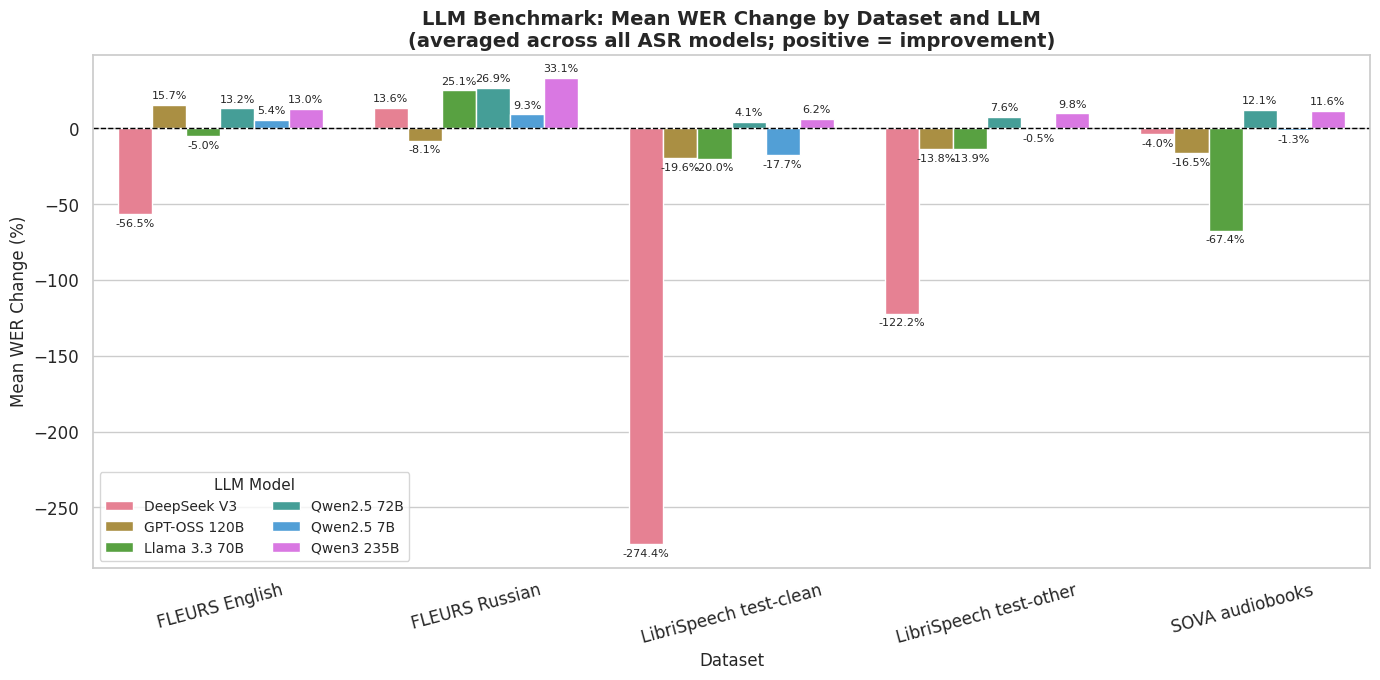

In [34]:
# график WER change by LLM x Dataset

agg_by_dataset = (
    analysis_df
    .groupby(['LLM', 'Dataset'])['WER Change (%)']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=agg_by_dataset,
    x='Dataset',
    y='WER Change (%)',
    hue='LLM',
    ax=ax,
    edgecolor='white',
)
ax.axhline(y=0, color='black', linewidth=1, ls='--')
ax.set_title(
    'LLM Benchmark: Mean WER Change by Dataset and LLM\n'
    '(averaged across all ASR models; '
    'positive = improvement)',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Mean WER Change (%)', fontsize=12)
ax.legend(
    title='LLM Model',
    fontsize=10,
    title_fontsize=11,
    loc='best',
    ncol=2,
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=3,
    )
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



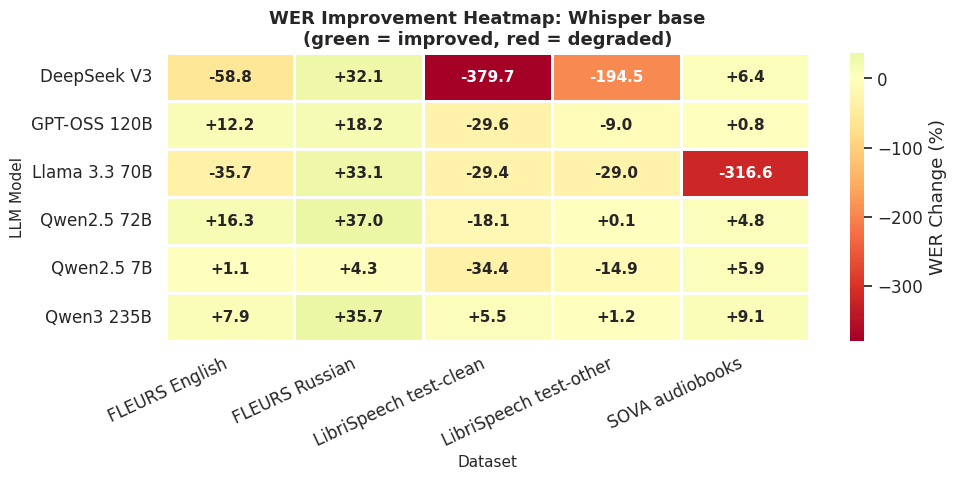

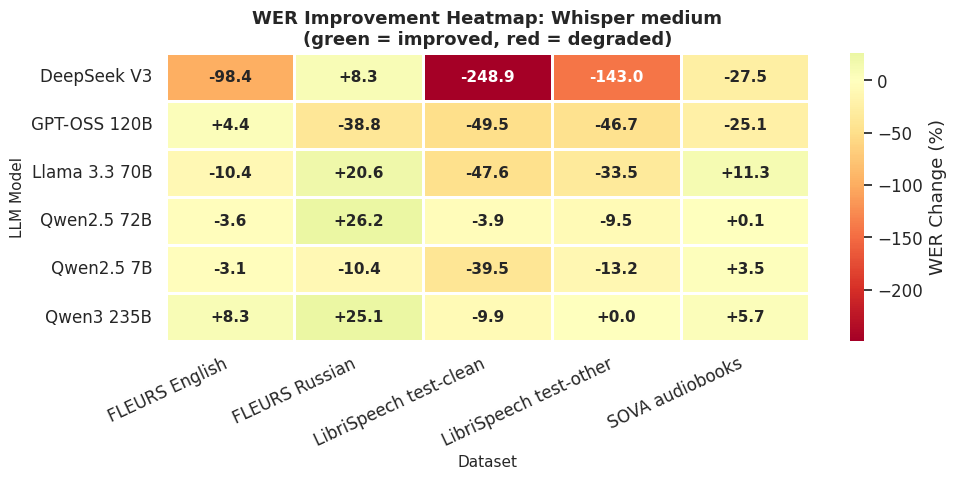

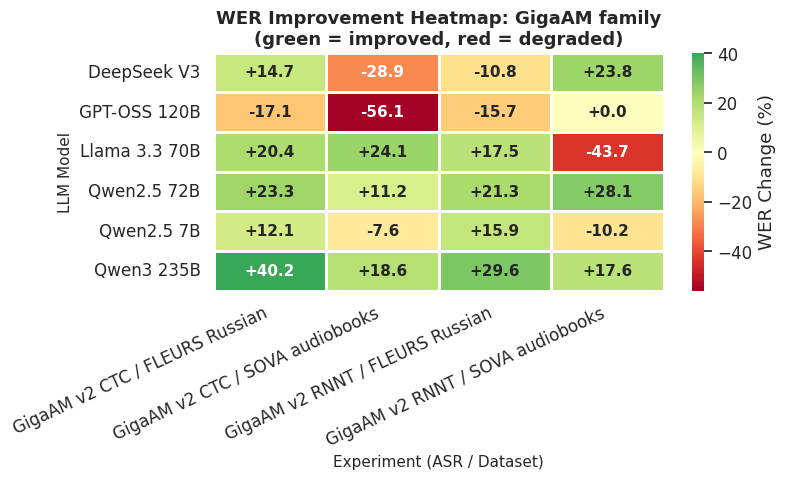

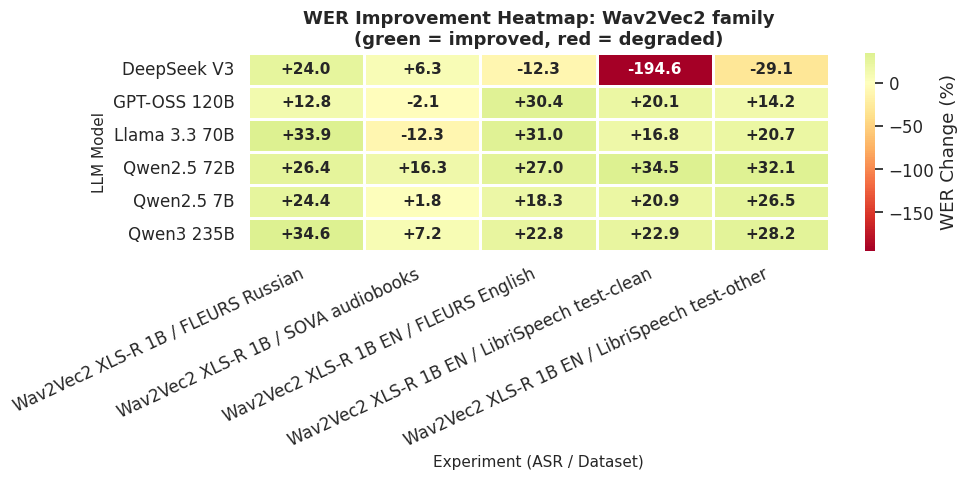

In [35]:
# график: WER Change heatmaps разбитые по ASR-семействам.

asr_groups = {
    'Whisper base': ['Whisper base'],
    'Whisper medium': ['Whisper medium'],
    'GigaAM family': ['GigaAM v2 CTC', 'GigaAM v2 RNNT'],
    'Wav2Vec2 family': [
        'Wav2Vec2 XLS-R 1B',
        'Wav2Vec2 XLS-R 1B EN',
    ],
}

for group_name, asr_list in asr_groups.items():
    group_df = analysis_df[analysis_df['ASR'].isin(asr_list)]

    if len(group_df) == 0:
        continue

    if len(asr_list) == 1:
        pivot = group_df.pivot(
            index='LLM',
            columns='Dataset',
            values='WER Change (%)',
        )
        xlabel_text = 'Dataset'
    else:
        pivot = group_df.pivot(
            index='LLM',
            columns='Experiment',
            values='WER Change (%)',
        )
        xlabel_text = 'Experiment (ASR / Dataset)'

    n_cols = len(pivot.columns)
    fig, ax = plt.subplots(figsize=(max(8, n_cols * 2), 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='+.1f',
        cmap='RdYlGn',
        center=0,
        linewidths=2,
        linecolor='white',
        ax=ax,
        annot_kws={'fontsize': 11, 'fontweight': 'bold'},
        cbar_kws={'label': 'WER Change (%)'},
    )
    ax.set_title(
        f'WER Improvement Heatmap: {group_name}\n'
        '(green = improved, red = degraded)',
        fontsize=13,
        fontweight='bold',
    )
    ax.set_xlabel(xlabel_text, fontsize=11)
    ax.set_ylabel('LLM Model', fontsize=11)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

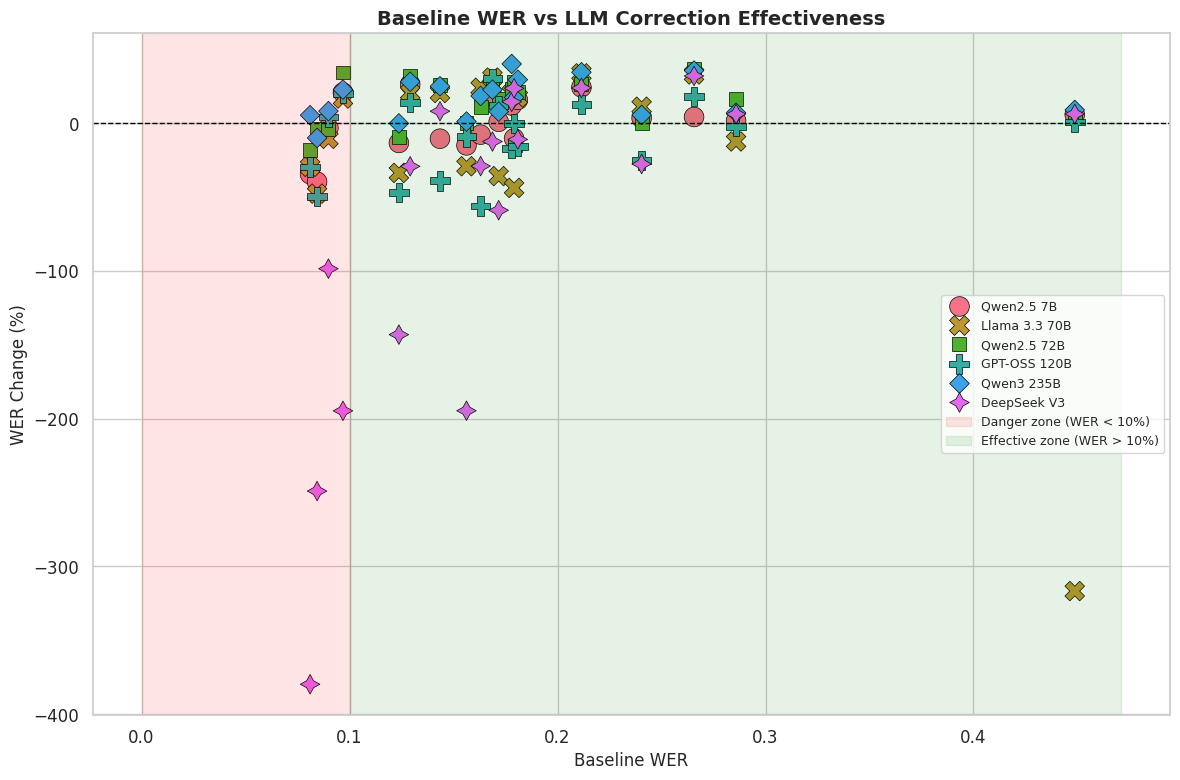

In [36]:
# график: Baseline WER vs LLM Effectiveness

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=analysis_df,
    x='Baseline WER',
    y='WER Change (%)',
    hue='LLM',
    style='LLM',
    s=200,
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
)

ax.axhline(y=0, color='black', ls='--', lw=1)
ax.axvspan(
    0, 0.10,
    alpha=0.1,
    color='red',
    label='Danger zone (WER < 10%)',
)
ax.axvspan(
    0.10, ax.get_xlim()[1],
    alpha=0.1,
    color='green',
    label='Effective zone (WER > 10%)',
)
ax.set_title(
    'Baseline WER vs LLM Correction Effectiveness',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Baseline WER', fontsize=12)
ax.set_ylabel('WER Change (%)', fontsize=12)
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()



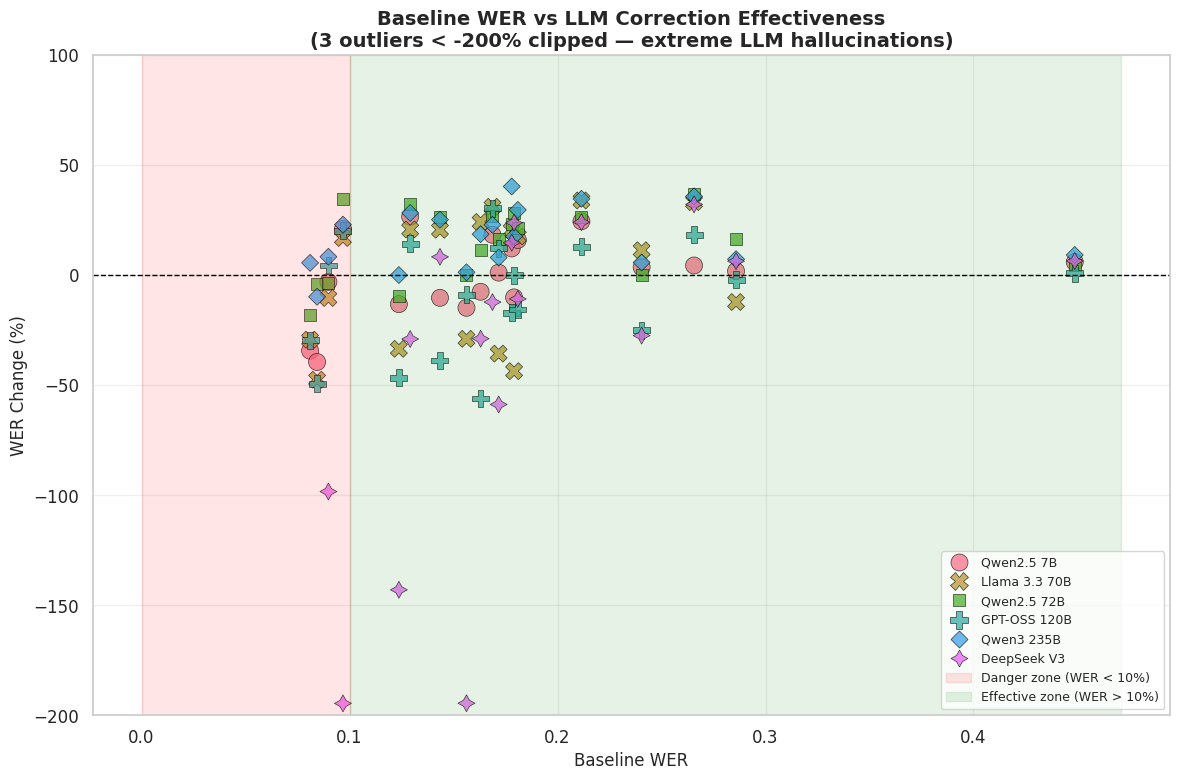

In [37]:
# график: Baseline WER vs LLM Effectiveness
# Ось Y ограничена диапазоном -200..+100


OUTLIER_THRESHOLD_MIN = -200
n_outliers = int(
    (analysis_df['WER Change (%)'] < OUTLIER_THRESHOLD_MIN).sum()
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=analysis_df,
    x='Baseline WER',
    y='WER Change (%)',
    hue='LLM',
    style='LLM',
    s=150,
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.75,
)
ax.axhline(y=0, color='black', ls='--', lw=1)
ax.axvspan(
    0, 0.10,
    alpha=0.1,
    color='red',
    label='Danger zone (WER < 10%)',
)
ax.axvspan(
    0.10, ax.get_xlim()[1],
    alpha=0.1,
    color='green',
    label='Effective zone (WER > 10%)',
)
ax.set_ylim(OUTLIER_THRESHOLD_MIN, 100)
title = (
    'Baseline WER vs LLM Correction Effectiveness'
)
if n_outliers > 0:
    title += (
        f'\n({n_outliers} outliers < '
        f'{OUTLIER_THRESHOLD_MIN}% clipped — '
        'extreme LLM hallucinations)'
    )
ax.set_title(title, fontsize=14, fontweight='bold')
ax.set_xlabel('Baseline WER', fontsize=12)
ax.set_ylabel('WER Change (%)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

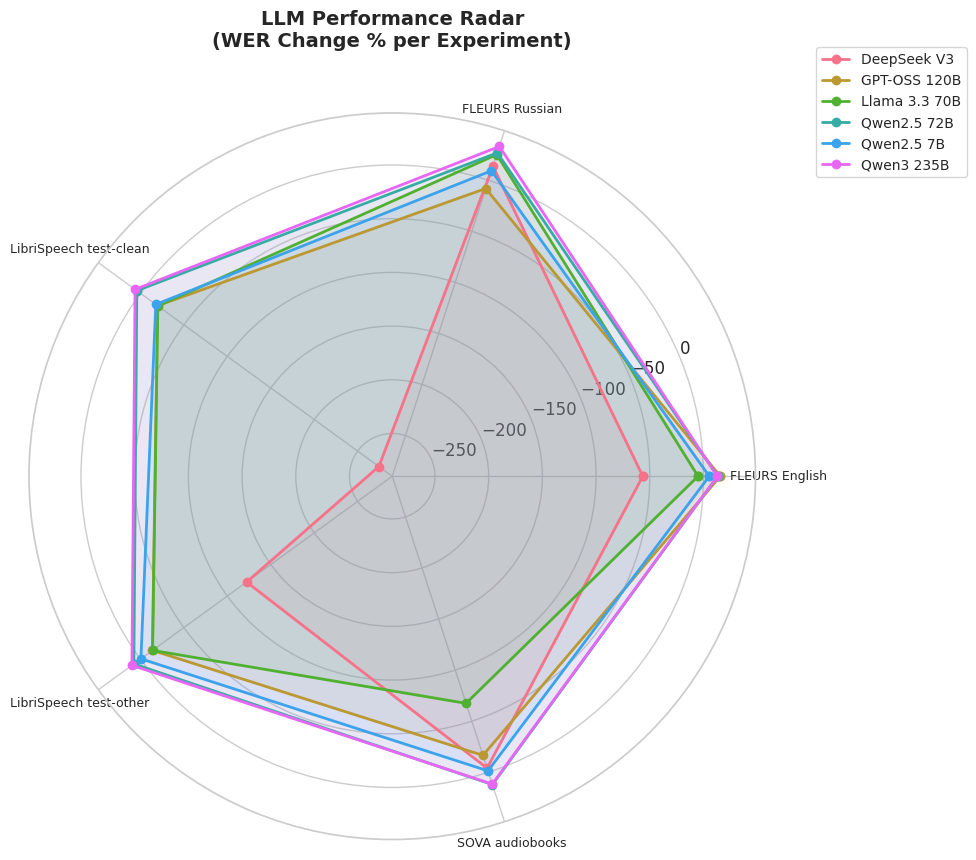

In [38]:
# график: LLM Radar by Dataset

radar_data = (
    analysis_df
    .groupby(['LLM', 'Dataset'])['WER Change (%)']
    .mean()
    .reset_index()
)
pivot_radar = radar_data.pivot(
    index='LLM',
    columns='Dataset',
    values='WER Change (%)',
)

categories = list(pivot_radar.columns)
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True),
)
colors = sns.color_palette('husl', len(pivot_radar))

for i, (llm, row) in enumerate(pivot_radar.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(
        angles, values, 'o-',
        linewidth=2, label=llm, color=colors[i],
    )
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title(
    'LLM Performance Radar\n(WER Change % per Experiment)',
    fontsize=14,
    fontweight='bold',
    y=1.08,
)
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1),
    fontsize=10,
)
plt.tight_layout()
plt.show()


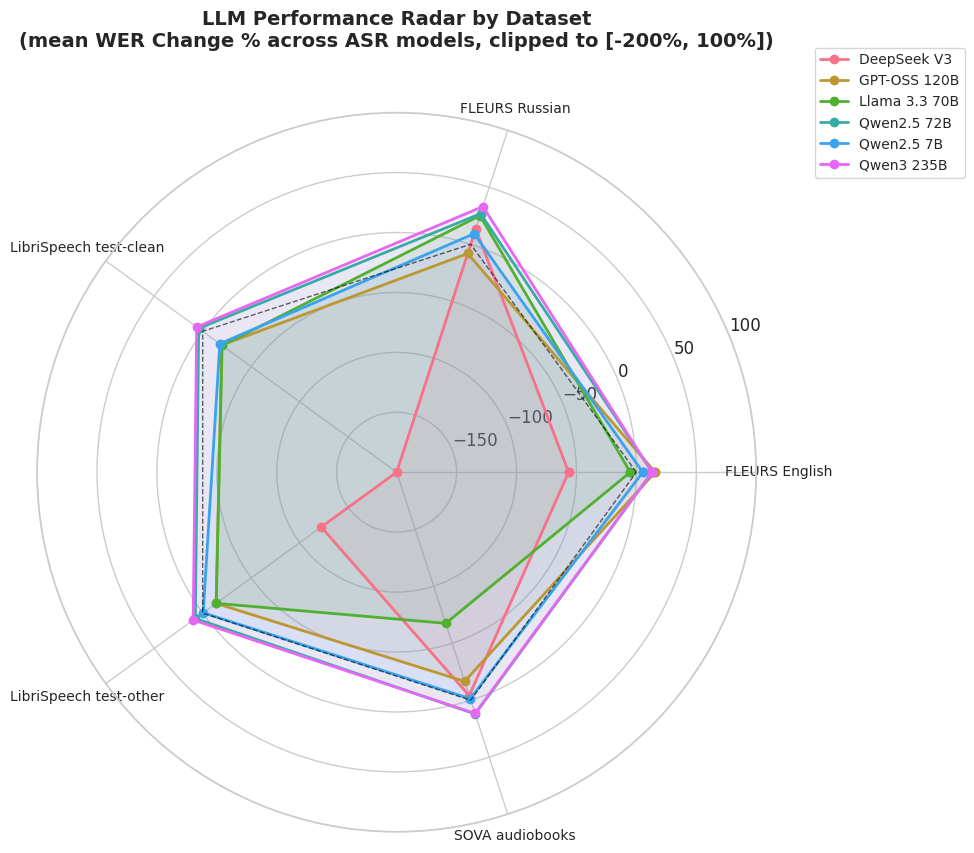

In [39]:
# график: LLM Radar by Dataset
# радиус обрезан до [-200, +100]

radar_data = (
    analysis_df
    .groupby(['LLM', 'Dataset'])['WER Change (%)']
    .mean()
    .reset_index()
)

RADAR_MIN = -200
RADAR_MAX = 100
radar_data['WER Change (clipped)'] = (
    radar_data['WER Change (%)'].clip(
        lower=RADAR_MIN, upper=RADAR_MAX,
    )
)

pivot_radar = radar_data.pivot(
    index='LLM',
    columns='Dataset',
    values='WER Change (clipped)',
)
categories = list(pivot_radar.columns)
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True),
)
colors = sns.color_palette('husl', len(pivot_radar))

for i, (llm, row) in enumerate(pivot_radar.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(
        angles, values, 'o-',
        linewidth=2, label=llm, color=colors[i],
    )
    ax.fill(angles, values, alpha=0.1, color=colors[i])

# Ось 0 — пунктирная для визуального «нулевого круга»
ax.plot(
    angles, [0] * len(angles),
    color='black', linewidth=1, linestyle='--', alpha=0.6,
)

ax.set_ylim(RADAR_MIN, RADAR_MAX)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title(
    'LLM Performance Radar by Dataset\n'
    '(mean WER Change % across ASR models, '
    f'clipped to [{RADAR_MIN}%, {RADAR_MAX}%])',
    fontsize=14,
    fontweight='bold',
    y=1.08,
)
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1),
    fontsize=10,
)
plt.tight_layout()
plt.show()

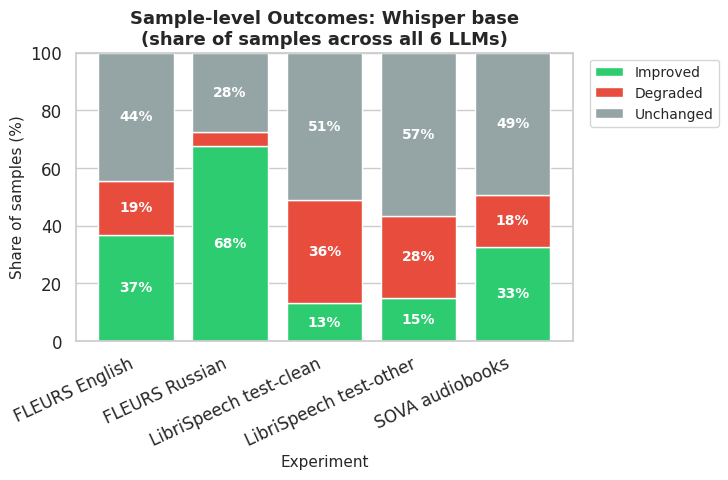

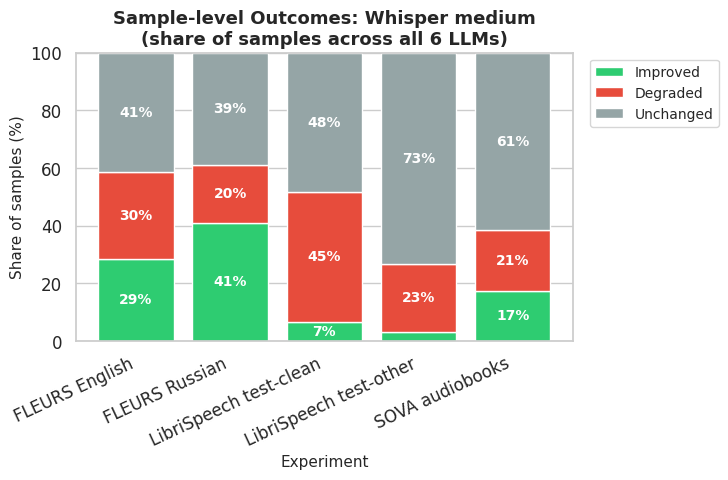

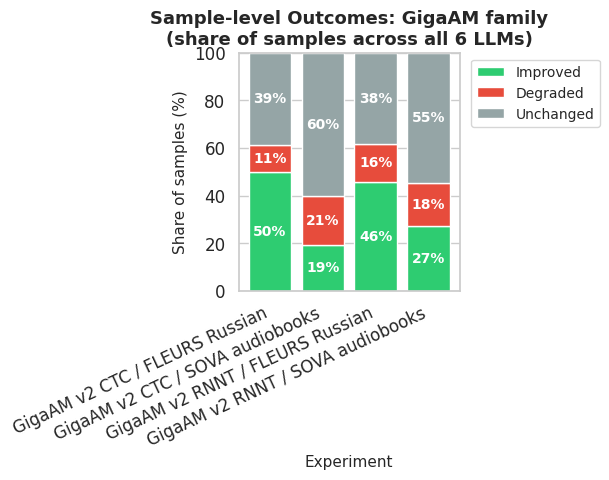

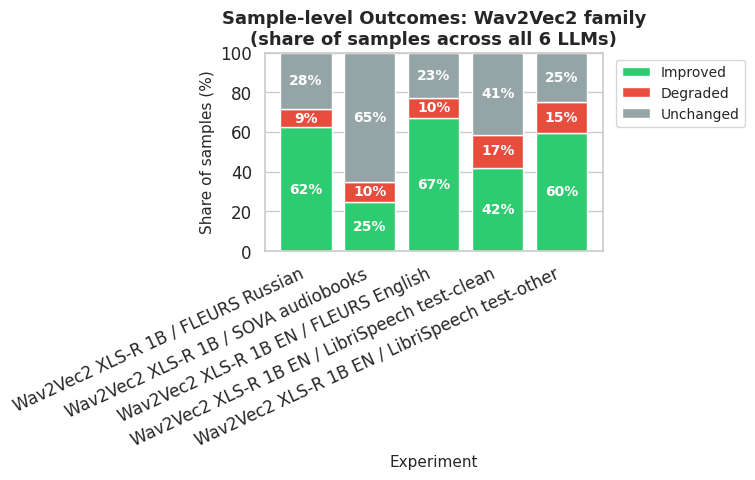

In [40]:
# график: Sample-level результаты по ASR-семействам.
# доли improved/degraded/unchanged
# среди всех сэмплов × всех LLM.

asr_groups = {
    'Whisper base': ['Whisper base'],
    'Whisper medium': ['Whisper medium'],
    'GigaAM family': ['GigaAM v2 CTC', 'GigaAM v2 RNNT'],
    'Wav2Vec2 family': [
        'Wav2Vec2 XLS-R 1B',
        'Wav2Vec2 XLS-R 1B EN',
    ],
}
colors = {
    'Improved': '#2ecc71',
    'Degraded': '#e74c3c',
    'Unchanged': '#95a5a6',
}

for group_name, asr_list in asr_groups.items():
    group_df = analysis_df[analysis_df['ASR'].isin(asr_list)]

    if len(group_df) == 0:
        continue

    if len(asr_list) == 1:
        group_df = group_df.assign(X=group_df['Dataset'])
    else:
        group_df = group_df.assign(
            X=group_df['ASR'] + ' / ' + group_df['Dataset']
        )

    counts = group_df.groupby('X').agg({
        'Improved': 'sum',
        'Degraded': 'sum',
        'Unchanged': 'sum',
    }).reset_index()

    # нормализуем: каждый столбик = 100%
    totals = (
        counts['Improved']
        + counts['Degraded']
        + counts['Unchanged']
    )
    counts['Improved %'] = counts['Improved'] / totals * 100
    counts['Degraded %'] = counts['Degraded'] / totals * 100
    counts['Unchanged %'] = counts['Unchanged'] / totals * 100

    fig, ax = plt.subplots(
        figsize=(max(6, len(counts) * 1.5), 5),
    )
    bottom = [0] * len(counts)
    for category in ['Improved', 'Degraded', 'Unchanged']:
        col_pct = f'{category} %'
        values = counts[col_pct].values
        ax.bar(
            counts['X'],
            values,
            bottom=bottom,
            label=category,
            color=colors[category],
            edgecolor='white',
        )
        # надпись только если доля > 5%
        for i, v in enumerate(values):
            if v > 5:
                ax.text(
                    i, bottom[i] + v / 2,
                    f'{v:.0f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white',
                )
        bottom = [b + v for b, v in zip(bottom, values)]

    ax.set_title(
        f'Sample-level Outcomes: {group_name}\n'
        '(share of samples across all 6 LLMs)',
        fontsize=13,
        fontweight='bold',
    )
    ax.set_xlabel('Experiment', fontsize=11)
    ax.set_ylabel('Share of samples (%)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(
        fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
    )
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

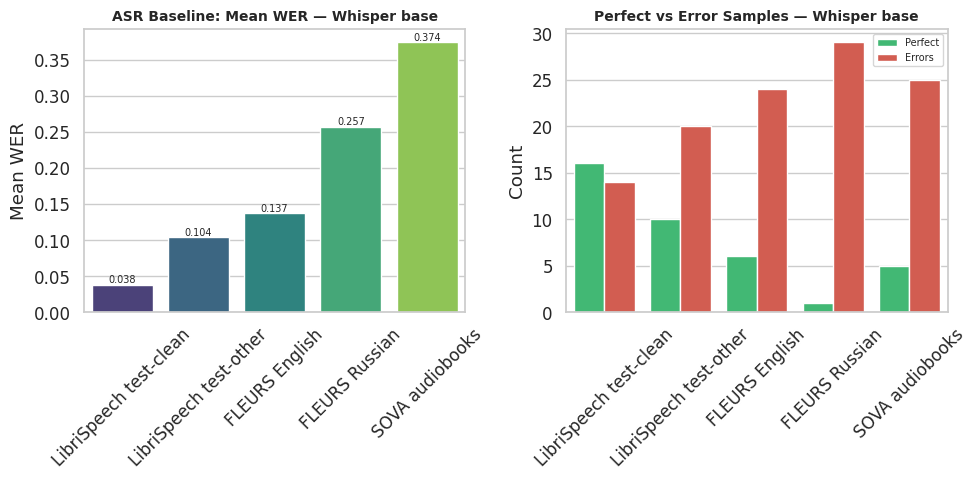

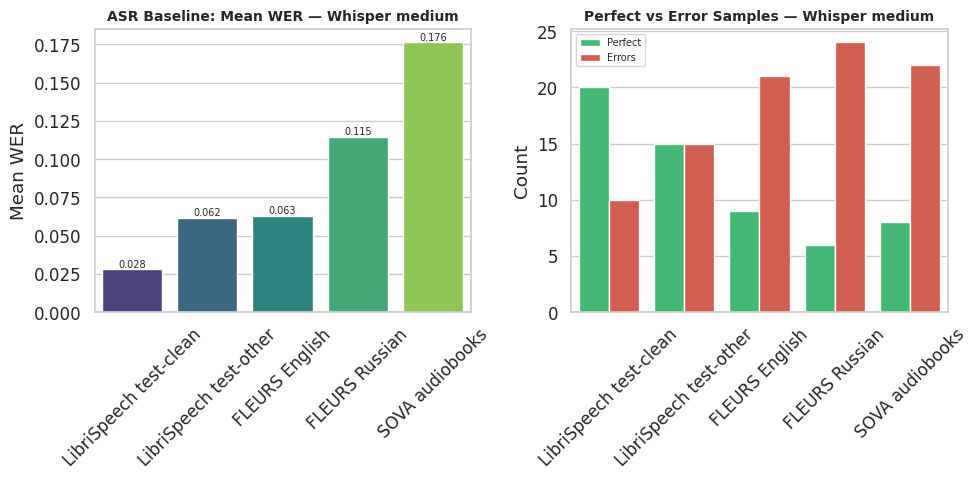

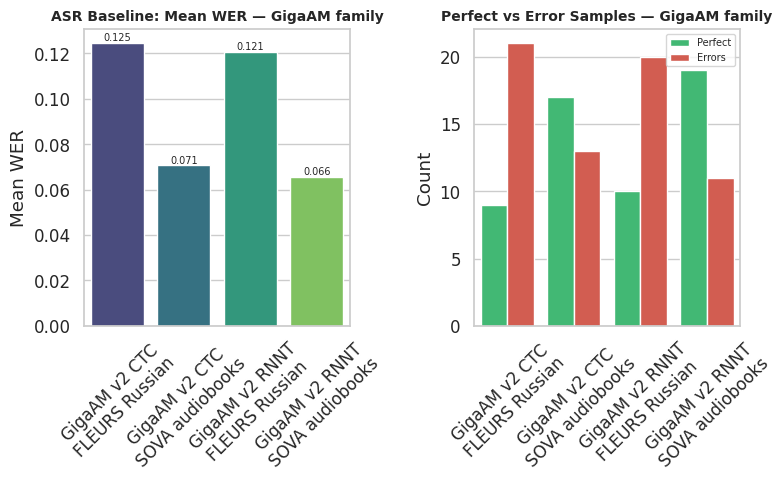

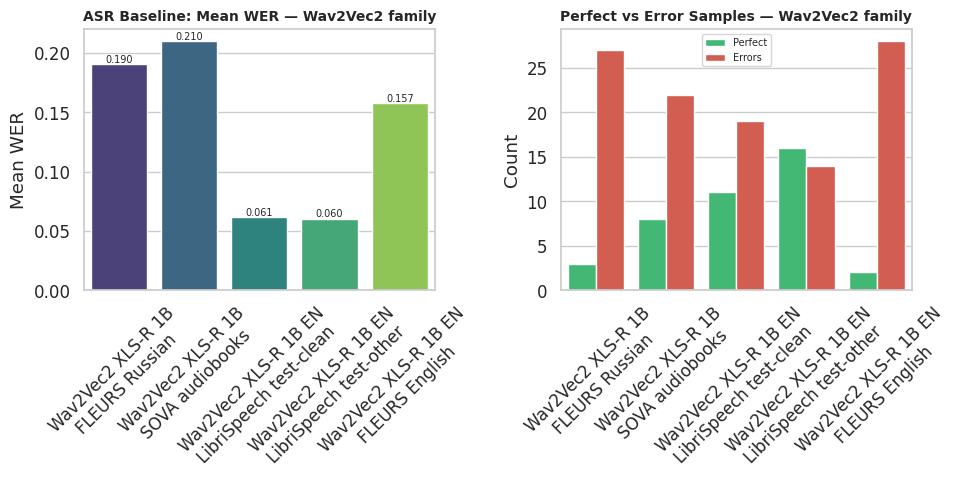

In [51]:
# график: ASR Baseline WER Comparison (без участия LLM)
# по ASR-семействам.

baseline_rows = []
for exp_key, exp in baselines_by_experiment.items():
    mean_wer = exp['df']['wer'].mean()
    errors = int((exp['df']['wer'] > 0).sum())
    perfect = int((exp['df']['wer'] == 0).sum())
    baseline_rows.append({
        'Experiment': exp_key,
        'ASR': exp['asr_display'],
        'Dataset': exp['dataset_display'],
        'Language': exp['language'],
        'Mean WER': mean_wer,
        'Errors': errors,
        'Perfect': perfect,
    })
baseline_view = pd.DataFrame(baseline_rows)

asr_groups = {
    'Whisper base': ['Whisper base'],
    'Whisper medium': ['Whisper medium'],
    'GigaAM family': ['GigaAM v2 CTC', 'GigaAM v2 RNNT'],
    'Wav2Vec2 family': [
        'Wav2Vec2 XLS-R 1B',
        'Wav2Vec2 XLS-R 1B EN',
    ],
}

for group_name, asr_list in asr_groups.items():
    group_df = baseline_view[
        baseline_view['ASR'].isin(asr_list)
    ]
    if len(group_df) == 0:
        continue

    if len(asr_list) == 1:
        group_df = group_df.assign(X=group_df['Dataset'])
    else:
        group_df = group_df.assign(
            X=group_df['ASR'] + '\n' + group_df['Dataset']
        )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(8, len(group_df) * 2), 5),
    )

    # графики слева: mean WER
    sns.barplot(
        data=group_df,
        x='X',
        y='Mean WER',
        hue='X',
        ax=axes[0],
        palette='viridis',
        edgecolor='white',
        legend=False,
        errorbar=None,
    )
    axes[0].set_title(
        f'ASR Baseline: Mean WER — {group_name}',
        fontsize=10,
        fontweight='bold',
    )
    for container in axes[0].containers:
        axes[0].bar_label(
            container, fmt='%.3f', fontsize=7,
        )
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_xlabel('')

    # графики справа: perfect vs errors
    bl_melt = group_df.melt(
        id_vars='X',
        value_vars=['Perfect', 'Errors'],
        var_name='Type',
        value_name='Count',
    )
    sns.barplot(
        data=bl_melt,
        x='X',
        y='Count',
        hue='Type',
        ax=axes[1],
        palette=['#2ecc71', '#e74c3c'],
        edgecolor='white',
        errorbar=None,
    )
    axes[1].set_title(
        f'Perfect vs Error Samples — {group_name}',
        fontsize=10,
        fontweight='bold',
    )
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xlabel('')
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

## 10. Промежуточные выводы

### Baseline WER по моделям и датасетам (30 сэмплов)

| ASR | Dataset | Language | Baseline WER |
|-----|---------|----------|-------------|
| Whisper base | LibriSpeech test-clean | EN | 8.10% |
| Whisper base | LibriSpeech test-other | EN | 15.62% |
| Whisper base | FLEURS English | EN | 17.17% |
| Whisper base | FLEURS Russian | RU | 26.56% |
| Whisper base | SOVA audiobooks | RU | 44.87% |
| Whisper medium | LibriSpeech test-clean | EN | 8.44% |
| Whisper medium | LibriSpeech test-other | EN | 12.37% |
| Whisper medium | FLEURS English | EN | 8.98% |
| Whisper medium | FLEURS Russian | RU | 14.35% |
| Whisper medium | SOVA audiobooks | RU | 24.04% |
| GigaAM v2 CTC | FLEURS Russian | RU | 17.80% |
| GigaAM v2 CTC | SOVA audiobooks | RU | 16.30% |
| GigaAM v2 RNNT | FLEURS Russian | RU | 18.09% |
| GigaAM v2 RNNT | SOVA audiobooks | RU | 17.91% |
| Wav2Vec2 XLS-R 1B | FLEURS Russian | RU | 21.15% |
| Wav2Vec2 XLS-R 1B | SOVA audiobooks | RU | 28.58% |
| Wav2Vec2 XLS-R 1B EN | LibriSpeech test-clean | EN | 9.68% |
| Wav2Vec2 XLS-R 1B EN | LibriSpeech test-other | EN | 12.91% |
| Wav2Vec2 XLS-R 1B EN | FLEURS English | EN | 16.87% |

### WER Change (%) после LLM-коррекции: русский язык

Положительные значения означают улучшение, отрицательные - ухудшение.

| LLM | Whisper base FLEURS RU | Whisper base SOVA | Whisper med FLEURS RU | Whisper med SOVA | GigaAM CTC FLEURS | GigaAM CTC SOVA | GigaAM RNNT FLEURS | GigaAM RNNT SOVA | W2V2 FLEURS RU | W2V2 SOVA |
|-----|----------------------|-------------------|---------------------|-----------------|-------------------|----------------|-------------------|-----------------|---------------|-----------|
| Qwen2.5 7B | +4.3 | +5.9 | -10.4 | +3.5 | +12.1 | -7.6 | +15.9 | -10.2 | +24.4 | +1.8 |
| Llama 3.3 70B | +33.1 | -316.6 | +20.6 | +11.3 | +20.4 | +24.1 | +17.5 | -43.7 | +33.9 | -12.3 |
| Qwen2.5 72B | +37.0 | +4.8 | +26.2 | +0.1 | +23.3 | +11.2 | +21.3 | +28.1 | +26.4 | +16.3 |
| GPT-OSS 120B | +18.2 | +0.8 | -38.8 | -25.1 | -17.1 | -56.1 | -15.7 | 0.0 | +12.8 | -2.1 |
| Qwen3 235B | +35.7 | +9.1 | +25.1 | +5.7 | +40.2 | +18.6 | +29.6 | +17.6 | +34.6 | +7.2 |
| DeepSeek V3 | +32.1 | +6.4 | +8.3 | -27.5 | +14.7 | -28.9 | +43.9 | +23.8 | +24.0 | +6.3 |

### WER Change (%) после LLM-коррекции: английский язык

| LLM | Whisper base LS-clean | Whisper base LS-other | Whisper base FLEURS EN | Whisper med LS-clean | Whisper med LS-other | Whisper med FLEURS EN | W2V2 EN LS-clean | W2V2 EN LS-other | W2V2 EN FLEURS |
|-----|---------------------|---------------------|----------------------|--------------------|--------------------|---------------------|-----------------|-----------------|---------------|
| Qwen2.5 7B | -34.4 | -14.9 | +1.1 | -39.5 | -13.2 | -3.1 | +20.9 | +26.5 | +18.3 |
| Llama 3.3 70B | -29.4 | -29.0 | -35.7 | -47.6 | -33.5 | -10.4 | +16.8 | +20.7 | +31.0 |
| Qwen2.5 72B | -18.1 | +0.1 | +16.3 | -3.9 | -9.5 | -3.6 | +34.5 | +32.1 | +27.0 |
| GPT-OSS 120B | -29.6 | -9.0 | +12.2 | -49.5 | -46.7 | +4.4 | +20.1 | +14.2 | +30.4 |
| Qwen3 235B | +5.5 | +1.2 | +7.9 | -9.9 | 0.0 | +8.3 | +22.9 | +28.2 | +22.8 |
| DeepSeek V3 | -379.7 | -194.5 | -58.8 | -248.9 | -143.0 | -98.4 | -194.6 | -29.1 | -12.3 |

### Проверка гипотез

**Гипотеза 1: более крупные LLM дают лучшую коррекцию.**
Подтверждается частично. Переход Qwen2.5 7B к 72B дает значительный прирост на русском: FLEURS RU +4.3% к +37.0%, Wav2Vec2 +24.4% к +26.4%. Однако дальнейшее увеличение до 235B (MoE) не дает пропорционального эффекта. Ключевой фактор - не размер, а архитектура и качество обучения.

**Гипотеза 2: LLM-коррекция эффективнее при высоком baseline WER.**
Подтверждается. На SOVA audiobooks (baseline 44.87% для Whisper base) большинство LLM дают положительный эффект. На Wav2Vec2 FLEURS RU (baseline 21.15%) все LLM кроме GPT-OSS улучшают результат. На LibriSpeech test-clean (baseline 8.10%) почти все LLM ухудшают результат.

**Гипотеза 3: при низком baseline WER LLM-коррекция ухудшает результат.**
Подтверждается. На LibriSpeech test-clean (Whisper base WER 8.10%) пять из шести LLM дают отрицательный WER Change. Единственное исключение - Qwen3 235B (+5.5%), которая консервативна и часто не вносит изменений. На Whisper medium LibriSpeech test-clean (WER 8.44%) все LLM кроме Qwen3 ухудшают результат.

**Гипотеза 4: Dense-модели стабильнее MoE.**
Подтверждается для русского языка. Qwen2.5 72B (dense) стабильно улучшает все 10 русских экспериментов. GPT-OSS 120B (MoE) ухудшает 5 из 10. DeepSeek V3 (MoE) нестабилен: улучшает 7 из 10, но на SOVA и GigaAM CTC ухудшает значительно (-28.9%). Для английского языка картина сложнее: Qwen3 235B (MoE) на Whisper стабильнее чем Qwen2.5 72B (dense).

**Гипотеза 5: Whisper medium точнее Whisper base.**
Подтверждается. Средний baseline WER на русских датасетах: Whisper base 35.72%, Whisper medium 19.20% - снижение на 46%. На английских: Whisper base 13.63%, Whisper medium 9.93% - снижение на 27%. Наибольший эффект на SOVA audiobooks: 44.87% к 24.04% (снижение на 46%).

### Ключевые наблюдения

**1. Лучшая LLM для русского языка: Qwen2.5 72B (dense).**
Стабильно улучшает все русские эксперименты. Средний WER Change на RU: +17.3%. Qwen3 235B тоже показывает хорошие результаты (+22.2% средний), но значительно медленнее (16 секунд на сэмпл против 2-3 секунд у Qwen2.5 72B).

**2. Wav2Vec2 XLS-R 1B EN - наиболее благоприятный для LLM-коррекции.**
Все 6 LLM улучшают результат на всех трёх EN датасетах (кроме DeepSeek V3 с галлюцинациями). Средний WER Change: +21.5% (без DeepSeek). CTC-модель без языковой модели допускает лингвистические ошибки, которые LLM исправляет эффективно.

**3. DeepSeek V3 генерирует галлюцинации на английском языке.**
На всех английских экспериментах WER ухудшается на 12-380%. Модель добавляет пояснительный текст вместо коррекции. На русском языке работает адекватно (+6..+44%). Это мотивирует внедрение фонетической фильтрации замен (Идея B).

**4. Llama 3.3 70B нестабильна на SOVA audiobooks.**
На Whisper base x SOVA: -316.6%. На Whisper medium x SOVA: +11.3%. Вероятная причина - модель переводит литературный русский текст на английский при высоком baseline WER.

**5. Порог эффективности LLM-коррекции: baseline WER примерно 15%.**
При WER ниже 15% результаты нестабильны и зависят от конкретной LLM. При WER выше 15% большинство LLM дают положительный эффект. Это подтверждает необходимость confidence-aware подхода.



### Главный тезис работы

Предлагается двухкомпонентный метод LLM-коррекции ASR: (1) confidence-aware вызов - применение LLM только к низкоуверенным фрагментам, (2) фонетическая фильтрация замен - защита от галлюцинаций LLM. Метод оценивается на сравнительном бенчмарке из 6 ASR x 6 LLM x 5 датасетов для английского и русского языков, с детализацией по типам ошибок и устойчивостью к шуму.

Такой подход объединяет две независимые идеи улучшения, что позволяет показать их эффект раздельно и совместно через ablation study.

### План дальнейших экспериментов

**Confidence-aware вызов LLM (приоритет 1).** Использование token-level logprobs и no_speech_prob из Whisper для определения уверенности модели на уровне сегментов. LLM-коррекция применяется только к фрагментам с низким confidence. Текущие результаты прямо мотивируют этот подход: при baseline WER ниже 10% почти все LLM ухудшают результат. Для Wav2Vec2 и GigaAM, которые не предоставляют готовых confidence scores, планируется использовать расхождение N-best гипотез как прокси-метрику уверенности (по статьям Hu et al. и Radford et al.).

**Фонетическая фильтрация замен (приоритет 1).** Post-hoc фильтр на выходе LLM: для каждого заменённого слова проверяется фонетическая близость к оригиналу через расстояние Левенштейна. Если замена слишком далека от оригинала -откатывается к исходному варианту. Упрощённая реализация constrained decoding по статье Ma et al. Цель: устранение галлюцинаций LLM, особенно DeepSeek V3 на английском языке (-380% WER Change на LibriSpeech) и Llama 3.3 70B на SOVA (-317% WER Change).

**Классификация ошибок по типам (приоритет 2).** Разбивка WER на substitution, insertion и deletion через jiwer.process_words(). Анализ какие типы ошибок LLM исправляет лучше, а какие ухудшает. По статье Park et al. Цель: понять механизм коррекции и объяснить почему CTC-модели (Wav2Vec2) лучше поддаются LLM-коррекции чем encoder-decoder (Whisper).

**Сравнение стратегий промптинга (приоритет 2).** Текущий промпт - простая инструкция. Планируется сравнение с TAP-стилем (Task-Activating Prompting по статье Yang et al.): структурированный промпт с описанием задачи, форматом ответа и few-shot примерами. Один дополнительный эксперимент в бенчмарке для оценки влияния промпта на качество коррекции.

**Эксперименты с шумом (приоритет 3).** Добавление AWGN (аддитивный белый гауссов шум) на разных уровнях SNR и структурированных помех (фоновая речь других людей, транспортный шум, бытовые звуки) к аудио. Прогон бенчмарка на зашумлённых версиях тех же датасетов. Цель: показать область, где LLM-коррекция наиболее полезна. В шумных условиях N-best гипотезы ASR сильно расходятся, confidence падает, LLM вызывается чаще - ожидается максимальный положительный эффект коррекции.

**N-best гипотезы (приоритет 3).** Извлечение beam search N-best из Whisper через DecodingOptions(beam_size=5). Измерение расхождения между гипотезами как дополнительная прокси-метрика confidence. Связывается с confidence-aware подходом и экспериментами с шумом: при зашумлённом аудио N-best расходятся сильнее, что сигнализирует о необходимости LLM-коррекции.

